In [1]:
# WT-GRU Traffic Flow Prediction

import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [2]:
# Step 1: Load data
df = pd.read_csv("traffic_2hr_intervals.csv", parse_dates=["datetime"])
df.sort_values(by=["location", "datetime"], inplace=True)

In [3]:
# Step 2: Choose one location
location_id = df["location"].unique()[0]
df_location = df[df["location"] == location_id]

In [4]:
# Step 3: Scale 'flow' column
flow = df_location['flow'].values.reshape(-1, 1)
scaler = MinMaxScaler()
flow_scaled = scaler.fit_transform(flow).flatten()

In [5]:
# Step 4: Apply Discrete Wavelet Transform
cA, cD = pywt.dwt(flow_scaled, 'db1')  # Haar wavelet
wt_flow = cA  # Use approximation coefficients

In [6]:
# Step 5: Create time sequences
def create_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i+seq_len])
        y.append(series[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 24
X, y = create_sequences(wt_flow, sequence_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [8]:
# Step 6: Train/test split
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [9]:
# Step 7: Build GRU model
model = Sequential()
model.add(GRU(units=64, input_shape=(X_train.shape[1], 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(units=64))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mae')

c:\Users\mayan\OneDrive\Desktop\traffic flow prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# Step 8: Train model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.4707 - val_loss: 0.3478
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3426 - val_loss: 0.3242
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3366 - val_loss: 0.2869
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3058 - val_loss: 0.2916
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3012 - val_loss: 0.2784
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2930 - val_loss: 0.2793
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3006 - val_loss: 0.2681
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2992 - val_loss: 0.2712
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2799 - val_loss: 0.2579
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2752 - val_loss: 0.2503
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2874 - val_loss: 0.2364
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2773 - val_loss: 0.2452
E

In [11]:
# Step 9: Predict
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


In [12]:
# Step 10: Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"WT-GRU MAE: {mae:.3f}")
print(f"WT-GRU MSE: {mse:.3f}")
print(f"WT-GRU RMSE: {rmse:.3f}")

WT-GRU MAE: 0.130
WT-GRU MSE: 0.034
WT-GRU RMSE: 0.185


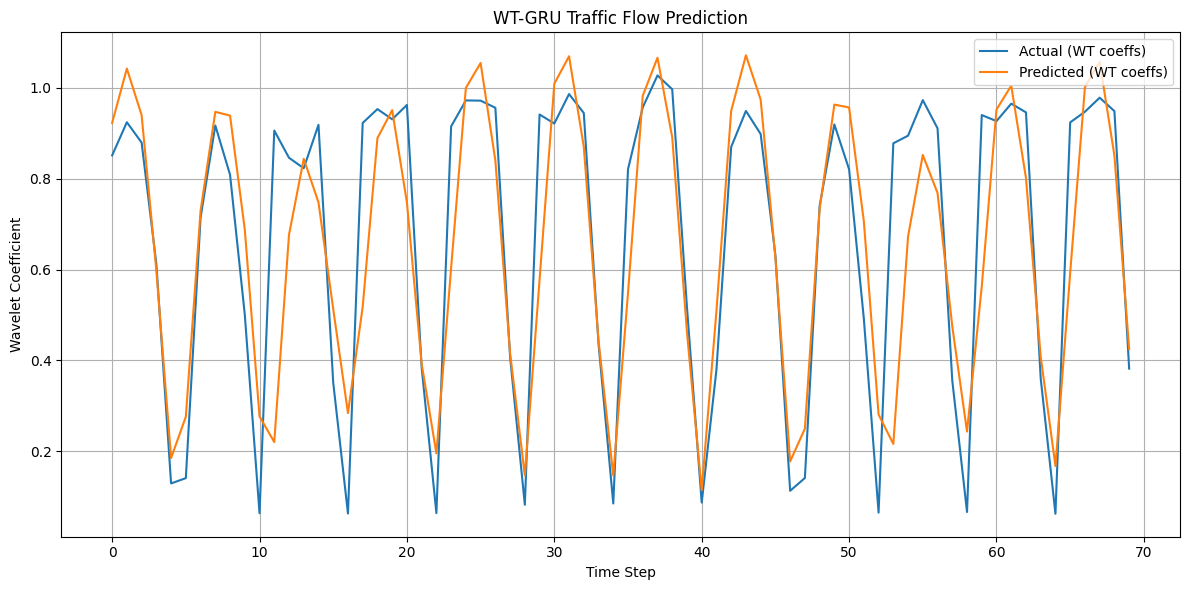

In [13]:
# Step 11: Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test[:200], label='Actual (WT coeffs)')
plt.plot(y_pred[:200], label='Predicted (WT coeffs)')
plt.title("WT-GRU Traffic Flow Prediction")
plt.xlabel("Time Step")
plt.ylabel("Wavelet Coefficient")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()